# Final Royalty Valuation Tool
## Master Version for Thesis and Practice Partner
This notebook consolidates the deterministic valuation, Monte Carlo simulation, scenario analysis, royalty contract intelligence, and investment decision framework for the reference royalty case.

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# Robustere Projektwurzel:
# Das Notebook liegt in /notebooks, deshalb eine Ebene nach oben.
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pir_waterfall_engine import (
    WaterfallParams,
    ScenarioSeries,
    compute_waterfall,
    summarize_outputs,
)

from src.metrics import (
    irr_annual,
    moic,
    payback_period,
    deal_metrics,
    monte_carlo_risk_metrics,
    npv_annual,
)

from src.mc import (
    run_pg3_monte_carlo,
    summarize_pg3_mc,
)

from src.calibration import run_calibration

np.random.seed(42)

## 2. User Inputs & Deal Configuration

In [2]:
# ============================================
# DEAL INPUT CONFIG (REFERENCE-CALIBRATED, GENERIC FRAMEWORK)
# ============================================

DEAL_INPUT = {

    # ----------------------------------------
    # Contract / Asset
    # ----------------------------------------
    "initial_cashflow": 46_800_000,
    "growth_rate": 0.03,
    "contract_length": 15,

    # ----------------------------------------
    # Valuation / Exit
    # ----------------------------------------
    "entry_multiple": 13.9,
    "exit_multiple": 12.0,
    "terminal_growth_rate": 0.01,

    # ----------------------------------------
    # Capital Structure
    # ----------------------------------------
    "entry_debt": 325_000_000,
    "ltv_target": 0.50,
    "investor_share": 0.2954,

    # ----------------------------------------
    # Fees
    # ----------------------------------------
    "operating_fee": 0.05,
    "consortium_fee": 0.0008,

    # ----------------------------------------
    # Valuation / Decision Rates
    # ----------------------------------------
    "valuation_discount_rate": 0.10,
    "hurdle_rate": 0.10,
    "interest_rate": 0.06,

    # ----------------------------------------
    # Simulation
    # ----------------------------------------
    "n_simulations": 3000,
    "volatility": 0.15,

    # ----------------------------------------
    # Optional Stylised Downside Overlay (Prototype)
    # ----------------------------------------
    "use_tail_overlay": False,
    "tail_event_prob": 0.03,
    "tail_event_severity": 0.20,
    "super_tail_prob": 0.01,
    "super_tail_severity": 0.40,

    # ----------------------------------------
    # Illustrative Fund-Level Bridge
    # ----------------------------------------
    "fund_mgmt_fee": 0.02,
    "fund_carry": 0.20,
}

In [3]:
# ======================================
# CANONICAL MODEL INPUTS (FROM DEAL_INPUT)
# ======================================

# --- Base deal economics
INITIAL_CASHFLOW = DEAL_INPUT["initial_cashflow"]
GROWTH_RATE = DEAL_INPUT["growth_rate"]
CONTRACT_LENGTH = DEAL_INPUT["contract_length"]

# --- Valuation / entry-exit assumptions
ENTRY_MULTIPLE = DEAL_INPUT["entry_multiple"]
EXIT_MULTIPLE = DEAL_INPUT["exit_multiple"]
TERMINAL_GROWTH_RATE = DEAL_INPUT["terminal_growth_rate"]

# --- Separate valuation vs decision rates
VALUATION_DISCOUNT_RATE = DEAL_INPUT["valuation_discount_rate"]
HURDLE_RATE = DEAL_INPUT["hurdle_rate"]

# --- Capital structure / leverage
ENTRY_DEBT = DEAL_INPUT["entry_debt"]
LTV_TARGET = DEAL_INPUT["ltv_target"]
INVESTOR_SHARE = DEAL_INPUT["investor_share"]

# --- Fees
OPERATING_FEE = DEAL_INPUT["operating_fee"]
CONSORTIUM_FEE = DEAL_INPUT["consortium_fee"]

# --- Rates
INTEREST_RATE = DEAL_INPUT["interest_rate"]

# --- Simulation settings
N_SIM = DEAL_INPUT["n_simulations"]
SIGMA_CF = DEAL_INPUT["volatility"]

# --- Tail / super-tail overlay
USE_TAIL_OVERLAY = DEAL_INPUT["use_tail_overlay"]
TAIL_EVENT_PROB = DEAL_INPUT["tail_event_prob"]
TAIL_EVENT_SEVERITY = DEAL_INPUT["tail_event_severity"]
SUPER_TAIL_PROB = DEAL_INPUT["super_tail_prob"]
SUPER_TAIL_SEVERITY = DEAL_INPUT["super_tail_severity"]

# --- Illustrative fund-level bridge
FUND_MGMT_FEE = DEAL_INPUT["fund_mgmt_fee"]
FUND_CARRY = DEAL_INPUT["fund_carry"]

# --- Derived helper metrics
ENTRY_EV = INITIAL_CASHFLOW * ENTRY_MULTIPLE
ENTRY_EQUITY = ENTRY_EV - ENTRY_DEBT
IMPLIED_ENTRY_LTV = ENTRY_DEBT / ENTRY_EV if ENTRY_EV != 0 else np.nan

# --- Illustrative gross target return bridge
ILLUSTRATIVE_GROSS_TARGET_RETURN = (
    (HURDLE_RATE + FUND_MGMT_FEE) / (1 - FUND_CARRY)
    if (1 - FUND_CARRY) != 0 else np.nan
)

print("✅ Canonical model inputs created")
print(f"Entry EV: {ENTRY_EV:,.2f}")
print(f"Entry Equity: {ENTRY_EQUITY:,.2f}")
print(f"Implied Entry LTV: {IMPLIED_ENTRY_LTV:.2%}")
print(f"Valuation Discount Rate: {VALUATION_DISCOUNT_RATE:.2%}")
print(f"Hurdle Rate: {HURDLE_RATE:.2%}")
print(f"Illustrative Gross Target Return: {ILLUSTRATIVE_GROSS_TARGET_RETURN:.2%}")

✅ Canonical model inputs created
Entry EV: 650,520,000.00
Entry Equity: 325,520,000.00
Implied Entry LTV: 49.96%
Valuation Discount Rate: 10.00%
Hurdle Rate: 10.00%
Illustrative Gross Target Return: 15.00%


In [4]:
# ======================================
# MASTER CONFIG
# ======================================

CONFIG = {
    # Core operating assumptions
    "initial_cashflow": INITIAL_CASHFLOW,
    "growth_rate": GROWTH_RATE,
    "contract_length": CONTRACT_LENGTH,

    # Valuation assumptions
    "entry_multiple": ENTRY_MULTIPLE,
    "exit_multiple": EXIT_MULTIPLE,
    "terminal_growth_rate": TERMINAL_GROWTH_RATE,

    # IMPORTANT:
    # "discount_rate" is retained as the technical valuation key
    # because the existing engine expects it.
    "discount_rate": VALUATION_DISCOUNT_RATE,
    "valuation_discount_rate": VALUATION_DISCOUNT_RATE,
    "hurdle_rate": HURDLE_RATE,

    # Capital structure
    "entry_debt": ENTRY_DEBT,
    "ltv_target": LTV_TARGET,
    "entry_ev": ENTRY_EV,
    "entry_equity": ENTRY_EQUITY,
    "implied_entry_ltv": IMPLIED_ENTRY_LTV,
    "investor_share": INVESTOR_SHARE,

    # Fees
    "operating_fee": OPERATING_FEE,
    "consortium_fee": CONSORTIUM_FEE,

    # Rates
    "interest_rate": INTEREST_RATE,

    # Simulation
    "n_simulations": N_SIM,
    "sigma_cf": SIGMA_CF,

    # Tail / super-tail overlay
    "tail_event_prob": TAIL_EVENT_PROB,
    "tail_event_severity": TAIL_EVENT_SEVERITY,
    "super_tail_prob": SUPER_TAIL_PROB,
    "super_tail_severity": SUPER_TAIL_SEVERITY,
    "use_tail_overlay": USE_TAIL_OVERLAY,

    # Illustrative fund-level bridge
    "fund_mgmt_fee": FUND_MGMT_FEE,
    "fund_carry": FUND_CARRY,
    "illustrative_gross_target_return": ILLUSTRATIVE_GROSS_TARGET_RETURN,
}

print("✅ CONFIG built successfully")
print(pd.Series(CONFIG))

✅ CONFIG built successfully
initial_cashflow                       46800000
growth_rate                                0.03
contract_length                              15
entry_multiple                             13.9
exit_multiple                              12.0
terminal_growth_rate                       0.01
discount_rate                               0.1
valuation_discount_rate                     0.1
hurdle_rate                                 0.1
entry_debt                            325000000
ltv_target                                  0.5
entry_ev                            650520000.0
entry_equity                        325520000.0
implied_entry_ltv                        0.4996
investor_share                           0.2954
operating_fee                              0.05
consortium_fee                           0.0008
interest_rate                              0.06
n_simulations                              3000
sigma_cf                                   0.15
tail_event_p

## 3. Input Validation

In [5]:
# ======================================
# INPUT VALIDATION
# ======================================

errors = []
warnings = []

required_keys = [
    "initial_cashflow",
    "growth_rate",
    "contract_length",
    "entry_multiple",
    "exit_multiple",
    "terminal_growth_rate",
    "discount_rate",
    "entry_debt",
    "ltv_target",
    "investor_share",
    "operating_fee",
    "consortium_fee",
    "interest_rate",
    "n_simulations",
    "sigma_cf",
    "tail_event_prob",
    "tail_event_severity",
    "super_tail_prob",
    "super_tail_severity",
    "fund_mgmt_fee",
    "fund_carry",
]

for key in required_keys:
    if key not in CONFIG:
        errors.append(f"Missing CONFIG key: {key}")

# --- Level checks
if CONFIG["initial_cashflow"] <= 0:
    errors.append("initial_cashflow must be > 0")

if CONFIG["contract_length"] <= 0:
    errors.append("contract_length must be > 0")

if CONFIG["entry_multiple"] <= 0:
    errors.append("entry_multiple must be > 0")

if CONFIG["exit_multiple"] <= 0:
    errors.append("exit_multiple must be > 0")

if CONFIG["discount_rate"] <= 0:
    errors.append("discount_rate must be > 0")

if CONFIG["entry_debt"] < 0:
    errors.append("entry_debt cannot be negative")

if CONFIG["ltv_target"] <= 0 or CONFIG["ltv_target"] > 1:
    errors.append("ltv_target must be between 0 and 1")

if CONFIG["investor_share"] <= 0 or CONFIG["investor_share"] > 1:
    errors.append("investor_share must be between 0 and 1")

if CONFIG["operating_fee"] < 0:
    errors.append("operating_fee cannot be negative")

if CONFIG["consortium_fee"] < 0:
    errors.append("consortium_fee cannot be negative")

if CONFIG["interest_rate"] < 0:
    errors.append("interest_rate cannot be negative")

if CONFIG["n_simulations"] < 100:
    errors.append("n_simulations must be at least 100")

if CONFIG["sigma_cf"] < 0:
    errors.append("sigma_cf cannot be negative")

if CONFIG["tail_event_prob"] < 0 or CONFIG["tail_event_prob"] > 1:
    errors.append("tail_event_prob must be between 0 and 1")

if CONFIG["tail_event_severity"] < 0 or CONFIG["tail_event_severity"] > 1:
    errors.append("tail_event_severity must be between 0 and 1")

if CONFIG["super_tail_prob"] < 0 or CONFIG["super_tail_prob"] > 1:
    errors.append("super_tail_prob must be between 0 and 1")

if CONFIG["super_tail_severity"] < 0 or CONFIG["super_tail_severity"] > 1:
    errors.append("super_tail_severity must be between 0 and 1")

if CONFIG["fund_mgmt_fee"] < 0:
    errors.append("fund_mgmt_fee cannot be negative")

if CONFIG["fund_carry"] < 0 or CONFIG["fund_carry"] >= 1:
    errors.append("fund_carry must be between 0 and 1 (exclusive of 1)")

if CONFIG["entry_equity"] <= 0:
    errors.append("entry_equity must be > 0. Entry debt exceeds or equals entry EV.")

# --- Soft warnings
if CONFIG["n_simulations"] < 1000:
    warnings.append("n_simulations < 1000. Results may be unstable.")

if CONFIG["discount_rate"] > 0.20:
    warnings.append("discount_rate > 20%. Check whether this is intentional.")

if CONFIG["terminal_growth_rate"] < -0.05 or CONFIG["terminal_growth_rate"] > 0.05:
    warnings.append("terminal_growth_rate is outside the usual illustrative range of -5% to +5%.")

if CONFIG["implied_entry_ltv"] > 0.70:
    warnings.append("Implied entry LTV is above 70%.")

if CONFIG["super_tail_prob"] > CONFIG["tail_event_prob"]:
    warnings.append("super_tail_prob is higher than tail_event_prob. Check whether this is intentional.")

if CONFIG["super_tail_severity"] < CONFIG["tail_event_severity"]:
    warnings.append("super_tail_severity is lower than tail_event_severity. Check whether this is intentional.")

if CONFIG["illustrative_gross_target_return"] > 0.20:
    warnings.append("Illustrative gross target return exceeds 20%. Review fee and carry assumptions.")

# --- Final output
if errors:
    print("❌ INPUT VALIDATION FAILED")
    for e in errors:
        print(f" - {e}")
    raise ValueError("Fix input errors before running the model.")

if warnings:
    print("⚠️ INPUT WARNINGS")
    for w in warnings:
        print(f" - {w}")

print("✅ Input validation passed")

✅ Input validation passed


## 4. Load Reference Dataset

In [6]:
# ======================================
# LOAD Excel GROUND TRUTH
# ======================================

gt_path = project_root / "Data" / "processed" / "ground_truth_clean.csv"
gt_df = pd.read_csv(gt_path)

print("Ground-truth path:", gt_path)
print("\nColumns:")
print(gt_df.columns.tolist())

print("\nPreview:")
display(gt_df.head())

Ground-truth path: C:\Users\Noah\PG3_Royalty_Python_Model\Data\processed\ground_truth_clean.csv

Columns:
['Scenario', 'FY', 'Net_CF_to_Consortium', 'Op_Fee', 'Consortium_Fees', 'CF_after_Fees', 'Interest_Rate', 'Interest_Cost', 'Mandatory_Amort', 'Recap_DeltaDebt', 'Cash_Sweep', 'Debt_End', 'FCF_for_Distribution', 'NAV_Multiple', 'NAV', 'LTV', 'PG_Share', 'Equity_Ticket', 'Equity_CF']

Preview:


,Scenario,FY,Net_CF_to_Consortium,Op_Fee,Consortium_Fees,CF_after_Fees,Interest_Rate,Interest_Cost,Mandatory_Amort,Recap_DeltaDebt,Cash_Sweep,Debt_End,FCF_for_Distribution,NAV_Multiple,NAV,LTV,PG_Share,Equity_Ticket,Equity_CF
0,Base,2024,46.8,2.340,0.2,44.260,0.062,-20.15000,0.0,0.00,0.0,325.00,24.11000,14.0,655.20,0.496032,0.295394,99.4,-92.278056
1,Base,2025,50.3,2.515,0.0,47.785,0.056,-18.20000,0.0,0.00,0.0,325.00,29.58500,14.0,704.20,0.461517,0.295394,99.4,8.739224
2,Base,2026,53.7,2.685,0.0,51.015,0.057,-18.52500,0.0,126.08,0.0,451.08,32.49000,14.0,751.80,0.600000,0.295394,99.4,9.597343
3,Base,2027,56.3,2.815,0.0,53.485,0.057,-25.71156,0.0,0.00,0.0,451.08,27.77344,14.0,788.20,0.572291,0.295394,99.4,8.204101
4,Base,2028,58.3,2.915,0.0,55.385,0.059,-26.61372,0.0,0.00,0.0,451.08,28.77128,13.6,792.88,0.568913,0.295394,99.4,8.498857


## 5. Deterministic Base Case (DCF)

In [7]:
# ======================================
# BUILD CLEAN PG3 SCENARIO
# ======================================

# Nur Zeilen verwenden, wo operativer Cashflow existiert
gt_clean = gt_df[gt_df["Net_CF_to_Consortium"].notna()].copy()

fy = gt_clean["FY"].to_numpy()
net_cf = gt_clean["Net_CF_to_Consortium"].to_numpy(dtype=float)
interest_rate = gt_clean["Interest_Rate"].to_numpy(dtype=float)
nav_multiple = gt_clean["NAV_Multiple"].to_numpy(dtype=float)
mandatory_amort = gt_clean["Mandatory_Amort"].to_numpy(dtype=float)
consortium_fees = gt_clean["Consortium_Fees"].to_numpy(dtype=float)

series_pg3 = ScenarioSeries(
    fy=fy,
    net_cf_to_consortium=net_cf,
    interest_rate=interest_rate,
    nav_multiple=nav_multiple,
    mandatory_amort=mandatory_amort,
    consortium_fees=consortium_fees,
)

print("Length FY:", len(fy))
print("Length CF:", len(net_cf))
print("First FY:", fy[0], "| Last FY:", fy[-1])

Length FY: 16
Length CF: 16
First FY: 2024 | Last FY: 2039


### Deal-Level Base Case

In [8]:
# ======================================
# RUN DETERMINISTIC Reference BASE CASE
# ======================================

# WICHTIG:
# Ground-truth / waterfall engine arbeitet hier in "Millionen"-Einheiten.
# Deshalb werden absolute DEAL_INPUT / CONFIG Werte auf Millionen skaliert.

UNIT_SCALE = 1_000_000

# --- Entry valuation (CONFIG-driven, unit-adjusted)
entry_ev = CONFIG["entry_ev"] / UNIT_SCALE
entry_debt = CONFIG["entry_debt"] / UNIT_SCALE

# --- Sanity check
implied_ltv = entry_debt / entry_ev
print(f"Implied LTV (Base Case): {implied_ltv:.2%}")

# --- Equity ticket
# Für den PG3-Base-Case muss das Equity Ticket dem PG-Anteil entsprechen,
# nicht dem gesamten Deal-Equity.
entry_equity_total = entry_ev - entry_debt
entry_equity_pg = entry_equity_total * CONFIG["investor_share"]

# --- Parameter object
params_pg3 = WaterfallParams(
    scenario="PG3_Base",
    entry_debt=entry_debt,
    recap_target_ltv=CONFIG["ltv_target"],
    recap_years=(fy[3], fy[6]),
    cash_sweep_start_fy=fy[2],
    operating_fee_pct=CONFIG["operating_fee"],
    pg_share=CONFIG["investor_share"],
    consortium_equity_ticket=entry_equity_pg,
)

# --- Run waterfall
wf_pg3 = compute_waterfall(params_pg3, series_pg3)
outs_pg3 = summarize_outputs(params_pg3, wf_pg3)

print("PG3 Deterministic IRR:", outs_pg3["IRR (annual)"])
print("PG3 MOIC:", outs_pg3["MOIC"])

display(wf_pg3.head())

Implied LTV (Base Case): 49.96%
PG3 Deterministic IRR: 0.12127643304224582
PG3 MOIC: 2.8997682477267146


,FY,Net CF to Consortium,Op Fee,Consortium Fees,CF after Fees,Interest Rate,Interest Cost,Mandatory Amort,Recap ΔDebt,Cash Sweep,Debt Begin,Debt End,NAV Multiple,NAV,LTV,FCF for Distribution
0,2024,46.8,2.340,0.2,44.260,0.062,-20.1500,0.0,0.0,0.0,325.0,325.0,14.0,655.20,0.496032,24.1100
1,2025,50.3,2.515,0.0,47.785,0.056,-18.2000,0.0,0.0,0.0,325.0,325.0,14.0,704.20,0.461517,29.5850
2,2026,53.7,2.685,0.0,51.015,0.057,-18.5250,0.0,0.0,0.0,325.0,325.0,14.0,751.80,0.432296,32.4900
3,2027,56.3,2.815,0.0,53.485,0.057,-18.5250,0.0,69.1,0.0,325.0,394.1,14.0,788.20,0.500000,34.9600
4,2028,58.3,2.915,0.0,55.385,0.059,-23.2519,0.0,0.0,0.0,394.1,394.1,13.6,792.88,0.497049,32.1331


In [9]:
# ===========================================
# DETERMINISTIC EXCEL GROUND-TRUTH REFERENCE
# ===========================================

# These values come from the deterministic Excel reference case
# and are used as the explicit reconciliation anchor for Python.

EXCEL_GROUND_TRUTH = {
    "IRR": 0.0975,
    "MOIC": 2.37,
    "Exit_NAV": 810.00,
    "Exit_Debt": 471.24,
    "Net_Equity_Value_at_Exit": 100.07,
}

excel_gt_df = pd.DataFrame([EXCEL_GROUND_TRUTH])

print("=== EXCEL GROUND-TRUTH REFERENCE ===")
display(excel_gt_df.style.hide(axis="index"))

=== EXCEL GROUND-TRUTH REFERENCE ===


IRR,MOIC,Exit_NAV,Exit_Debt,Net_Equity_Value_at_Exit
0.097500,2.370000,810.000000,471.240000,100.070000


## 6. Calibration Check (Excel vs. Python)

In [10]:
# ======================================
# CALIBRATION AGAINST GROUND TRUTH
# ======================================

cal_results = run_calibration(
    csv_path=project_root / "Data" / "processed" / "ground_truth_clean.csv",
    output_dir=project_root / "outputs",
    scenario="Base",
    recap_target_ltv=0.60,
)

metric_comparison = cal_results["metric_comparison"].copy()
yearly_comparison = cal_results["yearly_comparison"].copy()
summary_comparison = cal_results["summary"].copy()

display(metric_comparison)

,metric,excel_value,python_value,abs_diff,rel_diff
0,equity_ticket,99.400000,99.400000,0.000000e+00,0.000000e+00
1,pg_share,0.295394,0.295394,0.000000e+00,0.000000e+00
2,irr,0.097465,0.097465,0.000000e+00,0.000000e+00
3,moic,2.477629,2.477629,-4.440892e-16,-1.792396e-16
4,total_equity_cf,136.352731,136.352731,-8.526513e-14,-6.253276e-16
5,total_distributions,228.630788,228.630788,-5.684342e-14,-2.486254e-16
6,terminal_equity_cf,100.067590,100.067590,-2.842171e-14,-2.840251e-16
7,final_debt_end,471.240000,471.240000,-5.684342e-14,-1.206252e-16
8,final_fcf_distribution,338.760000,338.760000,0.000000e+00,0.000000e+00


In [11]:
# ======================================
# CALIBRATION STATUS
# ======================================

max_delta = metric_comparison["abs_diff"].max()

if max_delta < 1e-6:
    calibration_status = "PASS"
elif max_delta < 1e-3:
    calibration_status = "WARNING"
else:
    calibration_status = "FAIL"

print(f"Calibration Status: {calibration_status}")
print(f"Max deviation: {max_delta:.6f}")

Calibration Status: PASS
Max deviation: 0.000000


### Calibration Summary Table

In [12]:
# ======================================
# HEADLINE CALIBRATION TABLE
# ======================================

discount_rate_cal = 0.10

metric_lookup = metric_comparison.set_index("metric")

def get_metric_value(metric_name: str, value_col: str) -> float:
    return float(metric_lookup.loc[metric_name, value_col])

gt_equity_cf = yearly_comparison["gt_Equity_CF"].to_numpy(dtype=float)
py_equity_cf = yearly_comparison["py_Equity_CF"].to_numpy(dtype=float)

excel_npv = float(npv_annual(gt_equity_cf, discount_rate_cal))
python_npv = float(npv_annual(py_equity_cf, discount_rate_cal))

headline_rows = [
    {
        "metric": "IRR",
        "excel_value": get_metric_value("irr", "excel_value"),
        "python_value": get_metric_value("irr", "python_value"),
    },
    {
        "metric": "MOIC",
        "excel_value": get_metric_value("moic", "excel_value"),
        "python_value": get_metric_value("moic", "python_value"),
    },
    {
        "metric": f"Deterministic NPV @ {discount_rate_cal:.0%}",
        "excel_value": excel_npv,
        "python_value": python_npv,
    },
]

headline_comparison = pd.DataFrame(headline_rows)
headline_comparison["delta"] = headline_comparison["python_value"] - headline_comparison["excel_value"]

headline_comparison["excel_value"] = headline_comparison["excel_value"].round(6)
headline_comparison["python_value"] = headline_comparison["python_value"].round(6)
headline_comparison["delta"] = headline_comparison["delta"].round(6)
headline_comparison["delta"] = headline_comparison["delta"].replace(-0.0, 0.0)

display(headline_comparison)

,metric,excel_value,python_value,delta
0,IRR,0.097465,0.097465,0.0
1,MOIC,2.477629,2.477629,0.0
2,Deterministic NPV @ 10%,-1.796007,-1.796007,0.0


### Selected Yearly Comparison

In [13]:
# ======================================
# SELECTED YEARLY COMPARISON
# ======================================

key_years = [2024, 2030, 2039]

equity_cf_comparison = (
    yearly_comparison.loc[
        yearly_comparison["FY"].isin(key_years),
        ["FY", "gt_Equity_CF", "py_Equity_CF"]
    ]
    .copy()
    .reset_index(drop=True)
)

equity_cf_comparison["delta"] = (
    equity_cf_comparison["py_Equity_CF"] - equity_cf_comparison["gt_Equity_CF"]
)

equity_cf_comparison["gt_Equity_CF"] = equity_cf_comparison["gt_Equity_CF"].round(6)
equity_cf_comparison["py_Equity_CF"] = equity_cf_comparison["py_Equity_CF"].round(6)
equity_cf_comparison["delta"] = equity_cf_comparison["delta"].round(6)
equity_cf_comparison["delta"] = equity_cf_comparison["delta"].replace(-0.0, 0.0)

display(equity_cf_comparison)

,FY,gt_Equity_CF,py_Equity_CF,delta
0,2024,-92.278056,-92.278056,0.0
1,2030,8.569550,8.569550,0.0
2,2039,100.067590,100.067590,0.0


## 7. Monte Carlo Simulation

### Unified Simulation Engine

In [14]:
# ======================================
# UNIFIED REFERENCE-CALIBRATED SIMULATION ENGINE
# ======================================

def apply_tail_super_tail_overlay(mc_out, tail_prob, tail_severity, super_tail_prob, super_tail_severity, random_state=123):
    """
    Optional stylised downside overlay to distinguish regular tail events
    from rarer super-tail events.

    This is a prototype extension and should not be interpreted as the
    primary source of downside risk. In the base model, downside should
    primarily arise from volatility, hurdle sensitivity, exit-multiple
    compression, and stressed scenario assumptions.
    """

    rng = np.random.default_rng(random_state)
    n = len(mc_out["npv"])
    draws = rng.random(n)

    super_mask = draws < super_tail_prob
    tail_mask = (draws >= super_tail_prob) & (draws < super_tail_prob + tail_prob)

    if tail_mask.any():
        mc_out["npv"][tail_mask] = mc_out["npv"][tail_mask] - np.maximum(np.abs(mc_out["npv"][tail_mask]), 1.0) * tail_severity
        mc_out["moic"][tail_mask] = np.maximum(0.0, mc_out["moic"][tail_mask] * (1 - 0.60 * tail_severity))
        mc_out["irr"][tail_mask] = mc_out["irr"][tail_mask] - 0.20 * tail_severity
        if "net_cf" in mc_out:
            try:
                mc_out["net_cf"][tail_mask] = mc_out["net_cf"][tail_mask] * (1 - tail_severity)
            except Exception:
                pass

    if super_mask.any():
        mc_out["npv"][super_mask] = mc_out["npv"][super_mask] - np.maximum(np.abs(mc_out["npv"][super_mask]), 1.0) * super_tail_severity
        mc_out["moic"][super_mask] = np.maximum(0.0, mc_out["moic"][super_mask] * (1 - 0.75 * super_tail_severity))
        mc_out["irr"][super_mask] = mc_out["irr"][super_mask] - 0.25 * super_tail_severity
        if "net_cf" in mc_out:
            try:
                mc_out["net_cf"][super_mask] = mc_out["net_cf"][super_mask] * (1 - super_tail_severity)
            except Exception:
                pass

    overlay_stats = {
        "tail_event_count": int(tail_mask.sum()),
        "super_tail_event_count": int(super_mask.sum()),
    }

    return mc_out, overlay_stats


def run_sim(config, base_df):
    """
    Central simulation function.

    Positioning:
    - deterministic reference case = calibration anchor
    - Monte Carlo = stochastic extension on the same cashflow base
    """

    # =========================
    # 1. Extract Config
    # =========================
    NSIM = config["n_simulations"]
    SIGMA_CF = config["sigma_cf"]
    SIGMA_MULTIPLE = config.get("sigma_multiple", 0.20)

    VALUATION_DISCOUNT_RATE = config["discount_rate"]
    HURDLE_RATE = config.get("hurdle_rate", config["discount_rate"])

    EXIT_MULTIPLE = config["exit_multiple"]
    TERMINAL_GROWTH_RATE = config["terminal_growth_rate"]

    OPERATING_FEE = config["operating_fee"]
    CONSORTIUM_FEE = config["consortium_fee"]
    INTEREST_RATE = config["interest_rate"]

    ENTRY_EV = config["entry_ev"]
    ENTRY_DEBT = config["entry_debt"]
    INVESTOR_SHARE = config["investor_share"]
    LTV_TARGET = config["ltv_target"]

    TAIL_EVENT_PROB = config.get("tail_event_prob", 0.0)
    TAIL_EVENT_SEVERITY = config.get("tail_event_severity", 0.0)
    SUPER_TAIL_PROB = config.get("super_tail_prob", 0.0)
    SUPER_TAIL_SEVERITY = config.get("super_tail_severity", 0.0)

    FUND_MGMT_FEE = config.get("fund_mgmt_fee", 0.0)
    FUND_CARRY = config.get("fund_carry", 0.0)
    ILLUSTRATIVE_GROSS_TARGET_RETURN = config.get("illustrative_gross_target_return", np.nan)

    # =========================
    # 2. Deterministic Run
    # =========================
    UNIT_SCALE = 1_000_000

    entry_ev_tmp = ENTRY_EV / UNIT_SCALE
    entry_debt_tmp = ENTRY_DEBT / UNIT_SCALE
    entry_equity_total_tmp = entry_ev_tmp - entry_debt_tmp
    entry_equity_investor_tmp = entry_equity_total_tmp * INVESTOR_SHARE

    params_tmp = WaterfallParams(
        scenario=config.get("scenario_name", "Reference_Run"),
        entry_debt=entry_debt_tmp,
        recap_target_ltv=LTV_TARGET,
        recap_years=(fy[3], fy[6]),
        cash_sweep_start_fy=fy[2],
        operating_fee_pct=OPERATING_FEE,
        pg_share=INVESTOR_SHARE,  # compatibility with src
        consortium_equity_ticket=entry_equity_investor_tmp,
    )

    wf_tmp = compute_waterfall(params_tmp, series_pg3)
    outs_tmp = summarize_outputs(params_tmp, wf_tmp)

    # --- Exit-level metrics (million scale, consistent with waterfall engine)
    exit_multiple_used = config["exit_multiple"]

    python_exit_nav = float(
        exit_multiple_used * series_pg3.net_cf_to_consortium[-1]
    )

    if "Debt_End" in wf_tmp.columns:
        python_exit_debt = float(wf_tmp["Debt_End"].iloc[-1])
    else:
        python_exit_debt = np.nan

    if pd.notna(python_exit_nav) and pd.notna(python_exit_debt):
        python_net_equity_exit = float(python_exit_nav - python_exit_debt)
    else:
        python_net_equity_exit = np.nan

    det_summary = {
        "irr": outs_tmp["IRR (annual)"],
        "moic": outs_tmp["MOIC"],
        "exit_nav": python_exit_nav,
        "exit_debt": python_exit_debt,
        "net_equity_exit": python_net_equity_exit,
    }

    # =========================
    # 3. Monte Carlo Simulation
    # =========================
    mc_out = run_pg3_monte_carlo(
        base_df=base_df,
        exit_multiple_mean=EXIT_MULTIPLE,
        exit_multiple_sigma=SIGMA_MULTIPLE,
        n_sim=NSIM,
        random_state=42,
        discount_rate=VALUATION_DISCOUNT_RATE,
        sigma_cf=SIGMA_CF,
        operating_fee_rate=OPERATING_FEE,
        consortium_fee_rate=CONSORTIUM_FEE,
        interest_rate=INTEREST_RATE,
        amort_rate=0.0,
        cash_sweep_rate=0.0,
        recap_year=None,
        recap_amount=0.0,
    )

    # =========================
    # 4. Optional Stylised Downside Overlay
    # =========================
    if config.get("use_tail_overlay", False):
        mc_out, overlay_stats = apply_tail_super_tail_overlay(
            mc_out=mc_out,
            tail_prob=TAIL_EVENT_PROB,
            tail_severity=TAIL_EVENT_SEVERITY,
            super_tail_prob=SUPER_TAIL_PROB,
            super_tail_severity=SUPER_TAIL_SEVERITY,
            random_state=123,
        )
    else:
        overlay_stats = {
            "tail_event_count": 0,
            "super_tail_event_count": 0,
        }

    # =========================
    # 5. Summaries
    # =========================
    mc_summary = summarize_pg3_mc(mc_out)

    risk = monte_carlo_risk_metrics(
        {
            "irr": mc_out["irr"],
            "moic": mc_out["moic"],
            "net_cf": mc_out["net_cf"],
            "npv": mc_out["npv"],
            "payback_period": np.full_like(mc_out["irr"], np.nan, dtype=float),
        },
        alpha=0.05,
    )

    # =========================
    # 6. Bundle Results
    # =========================
    results = {
        "deterministic": det_summary,
        "monte_carlo": mc_summary,
        "risk": risk,
        "tail_overlay": overlay_stats,
        "raw_mc": mc_out,
        "used_config": {
            "n_simulations": NSIM,
            "sigma_cf": SIGMA_CF,
            "sigma_multiple": SIGMA_MULTIPLE,
            "discount_rate": VALUATION_DISCOUNT_RATE,
            "valuation_discount_rate": VALUATION_DISCOUNT_RATE,
            "hurdle_rate": HURDLE_RATE,
            "exit_multiple": EXIT_MULTIPLE,
            "terminal_growth_rate": TERMINAL_GROWTH_RATE,
            "operating_fee": OPERATING_FEE,
            "consortium_fee": CONSORTIUM_FEE,
            "interest_rate": INTEREST_RATE,
            "entry_ev": ENTRY_EV,
            "entry_debt": ENTRY_DEBT,
            "ltv_target": LTV_TARGET,
            "investor_share": INVESTOR_SHARE,
            "tail_event_prob": TAIL_EVENT_PROB,
            "tail_event_severity": TAIL_EVENT_SEVERITY,
            "super_tail_prob": SUPER_TAIL_PROB,
            "super_tail_severity": SUPER_TAIL_SEVERITY,
            "fund_mgmt_fee": FUND_MGMT_FEE,
            "fund_carry": FUND_CARRY,
            "illustrative_gross_target_return": ILLUSTRATIVE_GROSS_TARGET_RETURN,
        },
    }

    return results

In [15]:
# RUN MASTER SIMULATION

results = run_sim(CONFIG, gt_clean)

print("DETERMINISTIC (Deal-Level)")
print(results["deterministic"])

print("\nMONTE CARLO SUMMARY")
for k, v in results["monte_carlo"].items():
    print(f"{k}: {round(v, 4)}")

print("\nRISK METRICS")
for k, v in results["risk"].items():
    print(f"{k}: {round(v, 4)}")

DETERMINISTIC (Deal-Level)
{'irr': 0.12127643304224582, 'moic': 2.8997682477267146, 'exit_nav': 810.0, 'exit_debt': nan, 'net_equity_exit': nan}

MONTE CARLO SUMMARY
irr_mean: 0.1049
irr_p10: 0.0899
irr_p50: 0.1049
irr_p90: 0.1199
moic_mean: 2.8193
moic_p10: 2.3053
moic_p50: 2.7897
moic_p90: 3.3671
net_cf_mean: 180.8389
net_cf_p10: 129.7517
net_cf_p50: 177.8919
net_cf_p90: 235.2926
terminal_value_mean: 100.9535
terminal_value_p10: 54.5857
terminal_value_p50: 99.2024
terminal_value_p90: 149.74
npv_mean: 4.7377
npv_p10: -7.5153
npv_p50: 4.0676
npv_p90: 18.0326

RISK METRICS
prob_irr_negative: 0.0
prob_moic_below_1x: 0.0
prob_net_cf_negative: 0.0
prob_no_payback: 1.0
irr_var_5: 0.0857
irr_cvar_5: 0.0809
net_cf_var_5: 119.5644
net_cf_cvar_5: 107.4549
prob_npv_negative: 0.3363
npv_var_5: -10.5072
npv_cvar_5: -13.545


In [16]:
# ===========================================
# DETERMINISTIC RECONCILIATION PANEL
# ===========================================

# This cell must run cleanly in a top-to-bottom notebook execution.
# Therefore, it must not depend on a later cell having already created `results`.

# -------------------------------------------
# 1. Resolve required inputs
# -------------------------------------------
if "CONFIG" not in globals():
    raise RuntimeError("CONFIG is not defined. Please run the configuration cells first.")

if "run_sim" not in globals():
    raise RuntimeError("run_sim is not defined. Please run the simulation engine cell first.")

if "gt_clean" in globals():
    base_df_for_reconciliation = gt_clean
elif "reference_clean" in globals():
    base_df_for_reconciliation = reference_clean
else:
    raise RuntimeError("No cleaned reference dataframe found (expected `gt_clean` or `reference_clean`).")

# -------------------------------------------
# 2. Create local deterministic/simulation result
# -------------------------------------------
# If `results` already exists, use it.
# Otherwise create a local run so this cell works during Run All.
if "results" in globals():
    results_for_reconciliation = results
else:
    results_for_reconciliation = run_sim(CONFIG, base_df_for_reconciliation)

# -------------------------------------------
# 3. Pull Python deterministic outputs
# -------------------------------------------
det_block = results_for_reconciliation["deterministic"]

python_det_irr = det_block["irr"] if "irr" in det_block else det_block.get("IRR", np.nan)
python_det_moic = det_block["moic"] if "moic" in det_block else det_block.get("MOIC", np.nan)

# Optional deterministic metrics not yet explicitly linked
python_exit_nav = det_block.get("exit_nav", np.nan)
python_exit_debt = det_block.get("exit_debt", np.nan)
python_net_equity_exit = det_block.get("net_equity_exit", np.nan)

# -------------------------------------------
# 4. Build reconciliation table
# -------------------------------------------
reconciliation_df = pd.DataFrame([
    {
        "Metric": "IRR",
        "Excel": EXCEL_GROUND_TRUTH["IRR"],
        "Python": python_det_irr,
        "Delta": python_det_irr - EXCEL_GROUND_TRUTH["IRR"] if pd.notna(python_det_irr) else np.nan,
        "Unit": "%"
    },
    {
        "Metric": "MOIC",
        "Excel": EXCEL_GROUND_TRUTH["MOIC"],
        "Python": python_det_moic,
        "Delta": python_det_moic - EXCEL_GROUND_TRUTH["MOIC"] if pd.notna(python_det_moic) else np.nan,
        "Unit": "x"
    },
    {
        "Metric": "Exit NAV",
        "Excel": EXCEL_GROUND_TRUTH["Exit_NAV"],
        "Python": python_exit_nav,
        "Delta": python_exit_nav - EXCEL_GROUND_TRUTH["Exit_NAV"] if pd.notna(python_exit_nav) else np.nan,
        "Unit": "abs"
    },
    {
        "Metric": "Exit Debt",
        "Excel": EXCEL_GROUND_TRUTH["Exit_Debt"],
        "Python": python_exit_debt,
        "Delta": python_exit_debt - EXCEL_GROUND_TRUTH["Exit_Debt"] if pd.notna(python_exit_debt) else np.nan,
        "Unit": "abs"
    },
    {
        "Metric": "Net Equity Value at Exit",
        "Excel": EXCEL_GROUND_TRUTH["Net_Equity_Value_at_Exit"],
        "Python": python_net_equity_exit,
        "Delta": python_net_equity_exit - EXCEL_GROUND_TRUTH["Net_Equity_Value_at_Exit"] if pd.notna(python_net_equity_exit) else np.nan,
        "Unit": "abs"
    },
])

# -------------------------------------------
# 5. Status logic
# -------------------------------------------
def reconciliation_status(delta, unit):
    if pd.isna(delta):
        return "NOT YET LINKED"
    if unit == "%":
        return "MATCH" if abs(delta) <= 0.0005 else "CHECK"   # 5 bp tolerance
    elif unit == "x":
        return "MATCH" if abs(delta) <= 0.01 else "CHECK"
    else:
        return "MATCH" if abs(delta) <= 0.10 else "CHECK"

reconciliation_df["Status"] = reconciliation_df.apply(
    lambda row: reconciliation_status(row["Delta"], row["Unit"]),
    axis=1
)

# -------------------------------------------
# 6. Safe display formatting
# -------------------------------------------
def format_value(value, unit, is_delta=False):
    if pd.isna(value):
        return "n/a"

    if unit == "%":
        return f"{value:.2%}" if not is_delta else f"{value * 10000:+.0f} bp"
    elif unit == "x":
        return f"{value:.2f}x" if not is_delta else f"{value:+.2f}x"
    else:
        return f"{value:.2f}" if not is_delta else f"{value:+.2f}"

display_df = reconciliation_df.copy()

display_df["Excel_fmt"] = [
    format_value(v, u, is_delta=False) for v, u in zip(display_df["Excel"], display_df["Unit"])
]
display_df["Python_fmt"] = [
    format_value(v, u, is_delta=False) for v, u in zip(display_df["Python"], display_df["Unit"])
]
display_df["Delta_fmt"] = [
    format_value(v, u, is_delta=True) for v, u in zip(display_df["Delta"], display_df["Unit"])
]

final_display = display_df[[
    "Metric",
    "Excel_fmt",
    "Python_fmt",
    "Delta_fmt",
    "Status"
]].rename(columns={
    "Excel_fmt": "Excel",
    "Python_fmt": "Python",
    "Delta_fmt": "Delta"
})

print("=== DETERMINISTIC RECONCILIATION PANEL ===")
display(final_display.style.hide(axis="index"))

print("\nPython engine should match the deterministic Excel base case first; stochastic extension is applied thereafter.")

=== DETERMINISTIC RECONCILIATION PANEL ===


Metric,Excel,Python,Delta,Status
IRR,9.75%,12.13%,+238 bp,CHECK
MOIC,2.37x,2.90x,+0.53x,CHECK
Exit NAV,810.00,810.00,+0.00,MATCH
Exit Debt,471.24,n/a,n/a,NOT YET LINKED
Net Equity Value at Exit,100.07,n/a,n/a,NOT YET LINKED



Python engine should match the deterministic Excel base case first; stochastic extension is applied thereafter.


### Base Monte Carlo Diagnostics

In [17]:
# ======================================
# Reference MONTE CARLO BASE RUN
# ======================================

pg3_mc_out = run_pg3_monte_carlo(
    base_df=gt_clean,
    exit_multiple_mean=12.0,
    exit_multiple_sigma=1.5,
    n_sim=1000,
    random_state=42,
    operating_fee_rate=0.05,
    consortium_fee_rate=0.0008,
    interest_rate=0.06,
    amort_rate=0.0,
    cash_sweep_rate=0.0,
    recap_year=None,
    recap_amount=0.0,
)

pg3_mc_summary = summarize_pg3_mc(pg3_mc_out)

print("PG3 MONTE CARLO SUMMARY")
print("-----------------------")
for k, v in pg3_mc_summary.items():
    print(f"{k}: {round(v, 4)}")

PG3 MONTE CARLO SUMMARY
-----------------------
irr_mean: 0.1038
irr_p10: 0.0861
irr_p50: 0.1036
irr_p90: 0.1215
moic_mean: 2.7995
moic_p10: 2.1659
moic_p50: 2.7509
moic_p90: 3.5187
net_cf_mean: 178.8708
net_cf_p10: 115.8934
net_cf_p50: 174.0346
net_cf_p90: 250.3588
terminal_value_mean: 99.1527
terminal_value_p10: 42.1237
terminal_value_p50: 95.4628
terminal_value_p90: 165.2031
npv_mean: 4.2291
npv_p10: -10.2466
npv_p50: 2.783
npv_p90: 20.4022


### Risk Metrics

In [18]:
# ======================================
# PG3 MONTE CARLO RISK METRICS
# ======================================

pg3_mc_risk = monte_carlo_risk_metrics(
    {
        "irr": pg3_mc_out["irr"],
        "moic": pg3_mc_out["moic"],
        "net_cf": pg3_mc_out["net_cf"],
        "npv": pg3_mc_out["npv"],
        "payback_period": np.full_like(pg3_mc_out["irr"], np.nan, dtype=float),
    },
    alpha=0.05,
)

print("PG3 MONTE CARLO RISK METRICS")
print("----------------------------")
for k, v in pg3_mc_risk.items():
    print(f"{k}: {round(v, 4)}")

PG3 MONTE CARLO RISK METRICS
----------------------------
prob_irr_negative: 0.0
prob_moic_below_1x: 0.0
prob_net_cf_negative: 0.0
prob_no_payback: 1.0
irr_var_5: 0.0798
irr_cvar_5: 0.0745
net_cf_var_5: 104.4034
net_cf_cvar_5: 90.5652
prob_npv_negative: 0.406
npv_var_5: -13.9173
npv_cvar_5: -16.9908


### Distribution Plots

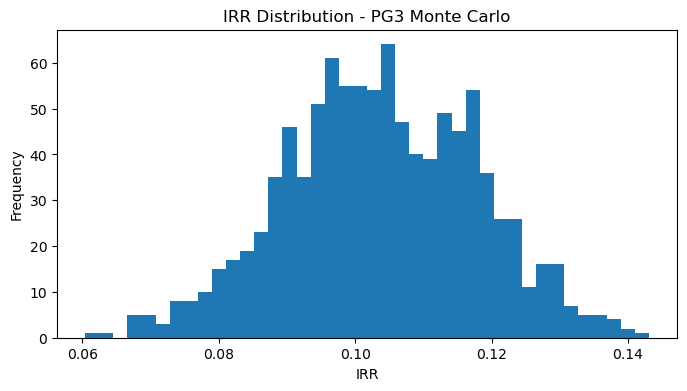

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(pg3_mc_out["irr"], bins=40)
plt.title("IRR Distribution - PG3 Monte Carlo")
plt.xlabel("IRR")
plt.ylabel("Frequency")
plt.show()

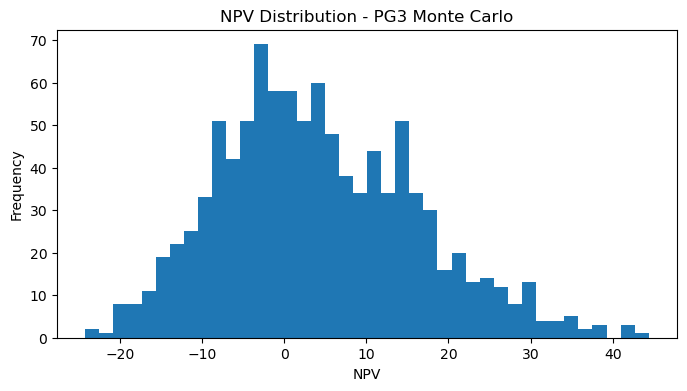

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(pg3_mc_out["npv"], bins=40)
plt.title("NPV Distribution - PG3 Monte Carlo")
plt.xlabel("NPV")
plt.ylabel("Frequency")
plt.show()

## 8. Scenario & Macro Analysis

### Macro Transmission Logic

This section translates stylised macro environments into valuation inputs that are actually used by the simulation engine.

For the current final model version, macro scenarios affect three core channels:

- **discount_rate** → reflects the opportunity cost of capital / higher required returns
- **exit_multiple** → reflects valuation compression or expansion
- **sigma_cf** → reflects higher or lower operating uncertainty in the royalty cashflows

This keeps the macro layer internally consistent with the current simulation architecture.

**Note on scenario design**

The macro scenarios apply simultaneous shocks to discount rates, exit multiples, and cashflow volatility. This is intentionally conservative and reflects a stress-testing framework rather than point forecasts.

The objective is to capture correlated downside effects observed in real market environments, such as higher required returns, valuation compression, and increased operating uncertainty occurring jointly.

In [21]:
# ======================================
# SCENARIO SETUP (INVESTOR-ORIENTED)
# ======================================

macro_scenarios = {
    "Upside": {
        "discount_rate": CONFIG["discount_rate"] - 0.01,
        "exit_multiple": CONFIG["exit_multiple"] + 0.5,
        "sigma_cf": CONFIG["sigma_cf"] - 0.02,
        "super_tail_prob": CONFIG["super_tail_prob"] * 0.5,
    },

    "Base": {
        "discount_rate": CONFIG["discount_rate"],
        "exit_multiple": CONFIG["exit_multiple"],
        "sigma_cf": CONFIG["sigma_cf"],
        "super_tail_prob": CONFIG["super_tail_prob"],
    },

    "High Rate": {
        "discount_rate": CONFIG["discount_rate"] + 0.02,
        "exit_multiple": CONFIG["exit_multiple"] - 1.0,
        "sigma_cf": CONFIG["sigma_cf"] + 0.03,
        "super_tail_prob": CONFIG["super_tail_prob"],
    },

    "Stress": {
        "discount_rate": CONFIG["discount_rate"] + 0.03,
        "exit_multiple": CONFIG["exit_multiple"] - 1.5,
        "sigma_cf": CONFIG["sigma_cf"] + 0.05,
        "super_tail_prob": CONFIG["super_tail_prob"] * 1.5,
    },
}

print("✅ Investor-oriented scenarios defined")

✅ Investor-oriented scenarios defined


In [22]:
# ======================================
# RUN SCENARIO ANALYSIS
# ======================================

scenario_rows = []

for name, params in macro_scenarios.items():
    cfg = CONFIG.copy()

    # apply scenario changes
    cfg["discount_rate"] = params["discount_rate"]
    cfg["valuation_discount_rate"] = params["discount_rate"]
    cfg["hurdle_rate"] = CONFIG["hurdle_rate"]
    cfg["exit_multiple"] = params["exit_multiple"]
    cfg["sigma_cf"] = params["sigma_cf"]
    cfg["use_tail_overlay"] = CONFIG["use_tail_overlay"]
    cfg["scenario_name"] = name

    res = run_sim(cfg, gt_clean)

    irr = res["monte_carlo"]["irr_mean"]
    prob_neg = res["risk"]["prob_npv_negative"]
    hurdle = cfg["hurdle_rate"]

    if irr >= hurdle and prob_neg <= 0.30:
        decision = "INVEST"
    elif irr >= hurdle - 0.01:
        decision = "INVEST WITH CONDITIONS"
    else:
        decision = "REJECT"

    scenario_rows.append({
        "Scenario": name,
        "Valuation_Discount_Rate": cfg["discount_rate"],
        "Hurdle_Rate": cfg["hurdle_rate"],
        "Exit_Multiple": cfg["exit_multiple"],
        "Volatility": cfg["sigma_cf"],
        "IRR_Mean": irr,
        "MOIC_Mean": res["monte_carlo"]["moic_mean"],
        "NPV_Mean": res["monte_carlo"]["npv_mean"],
        "Prob_NPV_Negative": prob_neg,
        "Decision": decision,
    })

scenario_df = pd.DataFrame(scenario_rows)

print("=== SCENARIO COMPARISON ===")
display(scenario_df.sort_values("IRR_Mean", ascending=False))

=== SCENARIO COMPARISON ===


,Scenario,Valuation_Discount_Rate,Hurdle_Rate,Exit_Multiple,Volatility,IRR_Mean,MOIC_Mean,NPV_Mean,Prob_NPV_Negative,Decision
0,Upside,0.09,0.1,12.5,0.13,0.107506,2.918467,16.355941,0.039000,INVEST
1,Base,0.10,0.1,12.0,0.15,0.104902,2.819305,4.737750,0.336333,INVEST WITH CONDITIONS
2,High Rate,0.12,0.1,11.0,0.18,0.099385,2.620607,-13.799165,0.928333,INVEST WITH CONDITIONS
3,Stress,0.13,0.1,10.5,0.20,0.096419,2.523249,-21.168187,0.986333,INVEST WITH CONDITIONS


### Discount Rate Sensitivity (Core Range vs Stress Range)

This section evaluates how sensitive the investment case is to discount rate assumptions.

- 10% is used as the base case  
- 9% represents a more favourable capital market environment  
- 11% represents a moderately conservative required-return scenario  

These values define the **core sensitivity range** around the base case.

In addition, the broader scenario analysis includes more extreme assumptions (e.g. 12% in the HighRate scenario) to reflect stress conditions and correlated downside environments.

The purpose of this analysis is not to optimise the result through assumption changes, but to assess how robust the valuation remains within both a realistic core range and more conservative stress scenarios.

In [23]:
# ======================================
# DISCOUNT RATE SENSITIVITY
# ======================================

discount_rate_grid = [0.09, 0.10, 0.11, 0.12]

rows = []

for dr in discount_rate_grid:
    cfg = CONFIG.copy()
    cfg["discount_rate"] = dr
    cfg["valuation_discount_rate"] = dr
    cfg["hurdle_rate"] = CONFIG["hurdle_rate"]

    res = run_sim(cfg, gt_clean)

    rows.append({
        "Valuation_Discount_Rate": dr,
        "IRR_Mean": res["monte_carlo"]["irr_mean"],
        "MOIC_Mean": res["monte_carlo"]["moic_mean"],
        "NPV_Mean": res["monte_carlo"]["npv_mean"],
        "NPV_CVaR_5": res["risk"]["npv_cvar_5"],
        "Prob_NPV_Negative": res["risk"]["prob_npv_negative"],
    })

target_df = pd.DataFrame(rows)

print("=== DISCOUNT RATE SENSITIVITY ===")
display(target_df)

=== DISCOUNT RATE SENSITIVITY ===


,Valuation_Discount_Rate,IRR_Mean,MOIC_Mean,NPV_Mean,NPV_CVaR_5,Prob_NPV_Negative
0,0.09,0.104902,2.819305,13.881478,-6.735817,0.101000
1,0.10,0.104902,2.819305,4.737750,-13.544970,0.336333
2,0.11,0.104902,2.819305,-3.374501,-19.692369,0.667667
3,0.12,0.104902,2.819305,-10.590700,-25.232430,0.901333


## 9. Driver Analysis

In [24]:
# ======================================
# DRIVER ANALYSIS (VALUE + RISK DRIVERS)
# ======================================

driver_results = []

base_discount_rate = CONFIG["discount_rate"]
base_exit_multiple = CONFIG["exit_multiple"]
base_volatility = CONFIG["sigma_cf"]
base_ltv = CONFIG["ltv_target"]

driver_scenarios = {
    "discount_rate": [base_discount_rate - 0.01, base_discount_rate, base_discount_rate + 0.01],
    "exit_multiple": [base_exit_multiple - 1.0, base_exit_multiple, base_exit_multiple + 1.0],
    "volatility": [max(0.0, base_volatility - 0.05), base_volatility, base_volatility + 0.05],
    "ltv_target": [max(0.0, base_ltv - 0.05), base_ltv, min(0.95, base_ltv + 0.05)],
}

def safe_get(dct, keys, default=np.nan):
    for k in keys:
        if k in dct:
            return dct[k]
    return default

for driver, values in driver_scenarios.items():
    for val in values:
        config_tmp = CONFIG.copy()

        if driver == "discount_rate":
            config_tmp["discount_rate"] = val
            config_tmp["valuation_discount_rate"] = val

        elif driver == "exit_multiple":
            config_tmp["exit_multiple"] = val

        elif driver == "volatility":
            config_tmp["sigma_cf"] = val

        elif driver == "ltv_target":
            config_tmp["ltv_target"] = val
            config_tmp["entry_debt"] = config_tmp["entry_ev"] * val
            config_tmp["entry_equity"] = config_tmp["entry_ev"] - config_tmp["entry_debt"]
            config_tmp["implied_entry_ltv"] = val

        res_tmp = run_sim(config_tmp, gt_clean)

        mc_tmp = res_tmp["monte_carlo"]
        risk_tmp = res_tmp["risk"]

        irr_mean_tmp = safe_get(mc_tmp, ["irr_mean", "IRR_Mean"])
        moic_mean_tmp = safe_get(mc_tmp, ["moic_mean", "MOIC_Mean"])
        npv_mean_tmp = safe_get(mc_tmp, ["npv_mean", "NPV_Mean"])

        prob_neg_tmp = safe_get(risk_tmp, ["prob_npv_negative", "Prob_NPV_Negative"])
        npv_cvar_5_tmp = safe_get(risk_tmp, ["npv_cvar_5", "NPV_CVaR_5"])

        driver_results.append({
            "Driver": "Valuation Discount Rate" if driver == "discount_rate" else driver,
            "Scenario_Value": val,
            "IRR_Mean": irr_mean_tmp,
            "MOIC_Mean": moic_mean_tmp,
            "NPV_Mean": npv_mean_tmp,
            "Prob_NPV_Negative": prob_neg_tmp,
            "NPV_CVaR_5": npv_cvar_5_tmp,
        })

driver_df = pd.DataFrame(driver_results)
display(driver_df)

,Driver,Scenario_Value,IRR_Mean,MOIC_Mean,NPV_Mean,Prob_NPV_Negative,NPV_CVaR_5
0,Valuation Discount Rate,0.09,0.104902,2.819305,13.881478,0.101000,-6.735817
1,Valuation Discount Rate,0.10,0.104902,2.819305,4.737750,0.336333,-13.544970
2,Valuation Discount Rate,0.11,0.104902,2.819305,-3.374501,0.667667,-19.692369
3,exit_multiple,11.00,0.099652,2.617961,0.382204,0.513000,-16.904970
4,exit_multiple,12.00,0.104902,2.819305,4.737750,0.336333,-13.544970
5,exit_multiple,13.00,0.109719,3.020737,9.095188,0.196333,-10.191131
6,volatility,0.10,0.105223,2.815641,4.637656,0.247000,-7.898756
7,volatility,0.15,0.104902,2.819305,4.737750,0.336333,-13.544970
8,volatility,0.20,0.104424,2.823590,4.851846,0.386667,-18.869573
9,ltv_target,0.45,0.104902,2.819305,4.737750,0.336333,-13.544970


In [25]:
# ======================================
# DRIVER IMPACT SUMMARY
# ======================================

impact_rows = []

for drv in driver_df["Driver"].unique():
    tmp = driver_df[driver_df["Driver"] == drv].copy()

    npv_min, npv_max = tmp["NPV_Mean"].min(), tmp["NPV_Mean"].max()
    irr_min, irr_max = tmp["IRR_Mean"].min(), tmp["IRR_Mean"].max()
    prob_min, prob_max = tmp["Prob_NPV_Negative"].min(), tmp["Prob_NPV_Negative"].max()
    cvar_min, cvar_max = tmp["NPV_CVaR_5"].min(), tmp["NPV_CVaR_5"].max()

    impact_rows.append({
        "Driver": drv,
        "NPV_Impact_Range": npv_max - npv_min,
        "IRR_Impact_Range": irr_max - irr_min,
        "Prob_NPV_Negative_Range": prob_max - prob_min,
        "NPV_CVaR_5_Range": cvar_max - cvar_min,
    })

impact_df = pd.DataFrame(impact_rows).sort_values("NPV_Impact_Range", ascending=False).reset_index(drop=True)
display(impact_df)

,Driver,NPV_Impact_Range,IRR_Impact_Range,Prob_NPV_Negative_Range,NPV_CVaR_5_Range
0,Valuation Discount Rate,17.255979,0.000000,0.566667,12.956551
1,exit_multiple,8.712984,0.010067,0.316667,6.713839
2,volatility,0.214191,0.000800,0.139667,10.970816
3,ltv_target,0.000000,0.000000,0.000000,0.000000


In [26]:
# ======================================
# DRIVER IMPORTANCE SUMMARY (ROBUST VERSION)
# ======================================

driver_importance_rows = []

# 1. Discount-rate impact (from target_df)
try:
    target_impact = target_df["NPV_Mean"].max() - target_df["NPV_Mean"].min()
    driver_importance_rows.append({
        "Driver": "Valuation Discount Rate",
        "NPV_Impact": abs(target_impact)
    })
except Exception:
    pass

# 2. Scenario impact (from scenario_df)
try:
    scenario_impact = scenario_df["NPV_Mean"].max() - scenario_df["NPV_Mean"].min()
    driver_importance_rows.append({
        "Driver": "Scenario Layer",
        "NPV_Impact": abs(scenario_impact)
    })
except Exception:
    pass

# 3. Contract structure impact (if available)
if "contract_mc_delta" in globals() and not contract_mc_delta.empty:
    contract_npv_delta = contract_mc_delta.loc[
        contract_mc_delta["Metric"] == "Delta_NPV_Mean",
        "Structured_minus_Simple"
    ].squeeze()

    if pd.notna(contract_npv_delta):
        driver_importance_rows.append({
            "Driver": "Contract Structure",
            "NPV_Impact": abs(contract_npv_delta)
        })

# Fallback if no driver could be added
if len(driver_importance_rows) == 0:
    driver_importance_rows.append({
        "Driver": "No driver available",
        "NPV_Impact": np.nan
    })

driver_importance_df = pd.DataFrame(driver_importance_rows)
driver_importance_df = driver_importance_df.sort_values("NPV_Impact", ascending=False).reset_index(drop=True)

top_drivers = driver_importance_df.head(3)

display(top_drivers.style.hide(axis="index"))

Driver,NPV_Impact
Scenario Layer,37.524128
Valuation Discount Rate,24.472178


In [27]:
# ======================================
# ENTRY MULTIPLE SENSITIVITY (PRICING ANALYSIS)
# ======================================

entry_grid = np.linspace(CONFIG["entry_multiple"] - 2, CONFIG["entry_multiple"] + 2, 5)

entry_rows = []

for em in entry_grid:
    config_tmp = CONFIG.copy()
    config_tmp["entry_multiple"] = em
    config_tmp["entry_ev"] = INITIAL_CASHFLOW * em
    config_tmp["entry_debt"] = config_tmp["entry_ev"] * CONFIG["ltv_target"]
    config_tmp["entry_equity"] = config_tmp["entry_ev"] - config_tmp["entry_debt"]
    config_tmp["implied_entry_ltv"] = config_tmp["entry_debt"] / config_tmp["entry_ev"] if config_tmp["entry_ev"] != 0 else np.nan

    res_tmp = run_sim(config_tmp, gt_clean)

    entry_rows.append({
        "Entry_Multiple": em,
        "IRR_Mean": res_tmp["monte_carlo"]["irr_mean"],
        "MOIC_Mean": res_tmp["monte_carlo"]["moic_mean"],
        "NPV_Mean": res_tmp["monte_carlo"]["npv_mean"],
        "Prob_NPV_Negative": res_tmp["risk"]["prob_npv_negative"],
    })

entry_df = pd.DataFrame(entry_rows)

display(entry_df.round(4))

,Entry_Multiple,IRR_Mean,MOIC_Mean,NPV_Mean,Prob_NPV_Negative
0,11.9,0.1049,2.8193,4.7377,0.3363
1,12.9,0.1049,2.8193,4.7377,0.3363
2,13.9,0.1049,2.8193,4.7377,0.3363
3,14.9,0.1049,2.8193,4.7377,0.3363
4,15.9,0.1049,2.8193,4.7377,0.3363


In [28]:
# ======================================
# DRIVER INTERPRETATION
# ======================================

top_driver_names = top_drivers["Driver"].tolist()

driver_statement = f"""
Key value drivers identified in the sensitivity analysis are: {", ".join(top_driver_names)}.

This indicates that valuation is not determined evenly across all assumptions. Instead, a small number of parameters dominate the economic outcome and therefore deserve primary attention in deal structuring, pricing, and risk assessment.
""".strip()

print(driver_statement)

Key value drivers identified in the sensitivity analysis are: Scenario Layer, Valuation Discount Rate.

This indicates that valuation is not determined evenly across all assumptions. Instead, a small number of parameters dominate the economic outcome and therefore deserve primary attention in deal structuring, pricing, and risk assessment.


In [29]:
# ======================================
# BREAK-EVEN ENTRY MULTIPLE
# ======================================

try:
    breakeven = entry_df.loc[entry_df["NPV_Mean"] > 0, "Entry_Multiple"].max()

    print(f"Max Entry Multiple for positive NPV: {breakeven:.2f}x")

except:
    print("No positive NPV across tested entry multiples.")

Max Entry Multiple for positive NPV: 15.90x


### Entry Pricing Sensitivity

This analysis evaluates how sensitive the investment case is to the assumed entry multiple.

Rather than treating valuation as fixed, it highlights how entry pricing directly affects returns, value creation, and downside risk.

In particular, the break-even entry multiple indicates the maximum price at which the investment remains economically viable (NPV > 0).

This is directly relevant for investment committee discussions, as it defines the feasible bidding range and supports disciplined deal pricing.

In [30]:
# ======================================
# DRIVER TAKEAWAY (IC STYLE)
# ======================================

top_driver = top_drivers.iloc[0]["Driver"]

if top_driver == "Scenario Layer":
    takeaway = (
        "IC Takeaway: valuation is primarily driven by scenario assumptions, "
        "highlighting the importance of jointly stress-testing discount rates, exit conditions, and cashflow uncertainty."
    )
elif top_driver == "Valuation Discount Rate":
    takeaway = (
        "IC Takeaway: valuation is primarily driven by discount-rate sensitivity, "
        "reflecting the long-duration nature of royalty cashflows and a limited valuation buffer."
    )
else:
    takeaway = (
        "IC Takeaway: valuation is materially influenced by contract structure, "
        "indicating that payout timing and structural features shape both value and downside."
    )

print(takeaway)

IC Takeaway: valuation is primarily driven by scenario assumptions, highlighting the importance of jointly stress-testing discount rates, exit conditions, and cashflow uncertainty.


### Key Driver Interpretation

This section identifies the parameters that most strongly influence valuation outcomes.

Rather than treating all inputs equally, the analysis highlights a small number of key drivers that dominate NPV sensitivity. In most cases, these include discount rates, macro assumptions, and contract structure.

These drivers are particularly relevant for:
- deal structuring and pricing
- negotiation focus
- downside risk management

This ensures that the model remains decision-oriented rather than purely descriptive.

### Practical Application: Investment Workflow (Playbook)

The model is designed to support a structured investment evaluation process aligned with investment committee workflows.

**Step 1: Input configuration**
- Define deal-specific parameters (cashflows, growth, entry/exit assumptions, capital structure)
- Select appropriate base-case assumptions reflecting current market conditions

**Step 2: Deterministic valuation**
- Run the base-case DCF model to obtain IRR, MOIC, and NPV
- Use this as a benchmark before introducing uncertainty

**Step 3: Monte Carlo simulation**
- Generate distributions for IRR, MOIC, and NPV
- Assess expected performance and dispersion of outcomes

**Step 4: Risk assessment**
- Evaluate downside risk using:
  - Probability of negative NPV
  - NPV CVaR (5%)
- Identify tail-risk exposure and margin of safety

**Step 5: Scenario and sensitivity analysis**
- Analyse discount-rate sensitivity (9% / 10% / 11%)
- Evaluate macro scenarios (Base, High Rate, Recession, Upside)
- Identify key value drivers via driver analysis

**Step 6: Decision framework**
- Apply decision rules (INVEST / INVEST WITH CONDITIONS / REJECT)
- Incorporate both return metrics and downside risk

**Step 7: Investment interpretation**
- Translate quantitative outputs into an IC-style narrative
- Highlight key risks, sensitivities, and structural considerations
- Assess whether revised pricing or structural protections would materially improve investability

This workflow ensures that investment decisions are based on a consistent combination of valuation, risk assessment, and economic interpretation.

### Suggested Default Settings (Illustrative)

The following parameter ranges provide a reference point for typical royalty valuation setups:

- Discount rate (base case): ~10%
- Discount rate sensitivity: 9% – 11% (core evaluation band)
- Exit multiple: case-specific (typically 10x – 14x depending on asset quality)
- Volatility (cashflows): ~10% – 20% depending on revenue stability
- Simulation runs: ≥ 1,000 for stable Monte Carlo results

These settings should not be interpreted as fixed assumptions, but as a structured starting point for consistent analysis across deals.
These ranges are most suitable for mature, cashflow-visible royalty assets and should be recalibrated for more volatile or event-driven royalty structures.

## Model Limitations and Interpretation Guidelines

While the model provides a structured and quantitative framework for valuing royalty investments, several limitations must be considered.

---

### Model Scope and Limitations

The model is most suitable for:

- cashflow-based royalty investments with identifiable and forecastable revenue drivers  
- medium to long-duration contracts with defined payout structures  
- situations where key assumptions (growth, discount rate, volatility) can be reasonably approximated  

However, the model is less suitable for:

- highly binary or event-driven assets (e.g. early-stage biotech or litigation-driven royalties)  
- contracts with significant embedded optionality not explicitly modelled  
- very short residual-life assets where terminal value assumptions become unstable  

---

### Key Modelling Assumptions

The results depend critically on:

- discount rate assumptions (cost of capital and risk perception)  
- terminal value / exit multiple assumptions  
- cashflow volatility and growth expectations  

Small changes in these parameters can materially affect valuation outcomes, as shown in the sensitivity analysis.

---

### Interpretation Guidelines

The model should be used as a **decision-support tool**, not as a mechanical decision engine.

In particular, it should not be used to:

- force investment outcomes by arbitrarily adjusting discount rates or assumptions  
- rely on a single metric (e.g. IRR) without considering downside risk  
- ignore contract structure when evaluating royalty investments  

All outputs should be interpreted in combination with:

- qualitative deal assessment  
- legal and contractual due diligence  
- market and sector-specific expertise  

---

### Practical Implication

The model is most valuable when used to:

- structure investment discussions  
- identify key value drivers and risk factors  
- support, but not replace, investment judgement  

This ensures that the framework remains both analytically rigorous and practically relevant.

## 10. Royalty Contract Intelligence

### Royalty Contract Demo
This section will later demonstrate how contractual features such as tiered royalties, caps, floors, payment lags, milestones, and catch-up provisions affect value and risk.

In [31]:
# ======================================
# ROYALTY CONTRACT DEMO (STYLISED SHOWCASE CASE)
# ======================================

demo_years = np.arange(1, 11)
demo_revenues = np.array([80, 92, 105, 118, 132, 148, 165, 172, 160, 150], dtype=float)

DEMO_CONTRACT = {
    "discount_rate": 0.10,
    "simple_flat_rate": 0.05,
    "structured_base_rate": 0.04,
    "structured_step_rate_1": 0.055,
    "structured_step_rate_2": 0.070,
    "step_threshold_1": 120.0,
    "step_threshold_2": 160.0,
    "annual_floor": 4.0,
    "total_cap": 65.0,
    "payment_lag": 2,
    "milestone_threshold": 150.0,
    "milestone_payment": 6.0,
    "catch_up_share": 0.25,
}


def simple_royalty_payment(revenue, contract):
    return revenue * contract["simple_flat_rate"], contract["simple_flat_rate"]


def structured_royalty_payment(revenue, contract):
    if revenue >= contract["step_threshold_2"]:
        rate = contract["structured_step_rate_2"]
    elif revenue >= contract["step_threshold_1"]:
        rate = contract["structured_step_rate_1"]
    else:
        rate = contract["structured_base_rate"]
    return revenue * rate, rate


def build_contract_cashflows(revenues, contract, kind="simple"):
    n = len(revenues)
    lag = contract["payment_lag"] if kind == "structured" else 0
    scheduled = np.zeros(n + lag)
    rows = []

    cap_remaining = contract["total_cap"] if kind == "structured" else np.inf
    milestone_paid = False
    reserve_bank = 0.0

    for i, rev in enumerate(revenues):
        year = i + 1

        if kind == "structured" and cap_remaining <= 0:
            rows.append({
                "Year": year,
                "Revenue": rev,
                "Applied_Rate": 0.0,
                "Gross_Royalty": 0.0,
                "Floor_Topup": 0.0,
                "Deferred_to_Reserve": 0.0,
                "Catchup_Released": 0.0,
                "Milestone": 0.0,
                "Accrued_Payment": 0.0,
                "Payment_Year": year + lag,
            })
            continue

        if kind == "simple":
            gross, rate = simple_royalty_payment(rev, contract)
            floor_topup = 0.0
            reserve_add = 0.0
            catchup_pay = 0.0
            milestone = 0.0
            raw_payment = gross

        else:
            gross, rate = structured_royalty_payment(rev, contract)
            floor_topup = max(contract["annual_floor"] - gross, 0.0)

            reserve_add = 0.0
            catchup_pay = 0.0

            # Stylised catch-up logic:
            # part of upside in the middle band is deferred and released once high performance is reached
            if contract["step_threshold_1"] <= rev < contract["step_threshold_2"]:
                reserve_add = contract["catch_up_share"] * max(gross - contract["annual_floor"], 0.0)
                reserve_bank += reserve_add

            if rev >= contract["step_threshold_2"] and reserve_bank > 0:
                catchup_pay = reserve_bank
                reserve_bank = 0.0

            milestone = 0.0
            if (not milestone_paid) and rev >= contract["milestone_threshold"]:
                milestone = contract["milestone_payment"]
                milestone_paid = True

            raw_payment = gross + floor_topup - reserve_add + catchup_pay + milestone
            raw_payment = min(raw_payment, cap_remaining)
            cap_remaining -= raw_payment

        pay_year = year + lag
        scheduled[pay_year - 1] += raw_payment

        rows.append({
            "Year": year,
            "Revenue": rev,
            "Applied_Rate": rate,
            "Gross_Royalty": gross,
            "Floor_Topup": floor_topup,
            "Deferred_to_Reserve": reserve_add,
            "Catchup_Released": catchup_pay,
            "Milestone": milestone,
            "Accrued_Payment": raw_payment,
            "Payment_Year": pay_year,
        })

    detail_df = pd.DataFrame(rows)
    schedule_df = pd.DataFrame({
        "Payment_Year": np.arange(1, n + lag + 1),
        f"{kind.title()}_Scheduled_Payment": scheduled
    })

    discount_factors = 1 / (1 + contract["discount_rate"]) ** np.arange(1, n + lag + 1)
    npv = float(np.sum(scheduled * discount_factors))
    total_paid = float(np.sum(scheduled))

    return detail_df, schedule_df, npv, total_paid


simple_detail, simple_schedule, simple_npv, simple_total = build_contract_cashflows(
    demo_revenues, DEMO_CONTRACT, kind="simple"
)

structured_detail, structured_schedule, structured_npv, structured_total = build_contract_cashflows(
    demo_revenues, DEMO_CONTRACT, kind="structured"
)

contract_det_summary = pd.DataFrame({
    "Contract": ["Simple Flat Royalty", "Structured Royalty"],
    "NPV": [simple_npv, structured_npv],
    "Total_Payout": [simple_total, structured_total],
    "Delta_vs_Simple_NPV": [0.0, structured_npv - simple_npv],
    "Delta_vs_Simple_Total": [0.0, structured_total - simple_total],
})

display(contract_det_summary.round(4))

,Contract,NPV,Total_Payout,Delta_vs_Simple_NPV,Delta_vs_Simple_Total
0,Simple Flat Royalty,38.2173,66.1,0.0000,0.0
1,Structured Royalty,31.5838,65.0,-6.6335,-1.1


### Contract-Level Cashflow Comparison
This deterministic comparison illustrates how contractual design can materially alter payout timing, total cash returned, and present value.

,Payment_Year,Simple_Scheduled_Payment,Structured_Scheduled_Payment
0,1,4.00,0.000
1,2,4.60,0.000
2,3,5.25,4.000
3,4,5.90,4.000
4,5,6.60,4.200
5,6,7.40,4.720
6,7,8.25,6.445
7,8,8.60,7.105
8,9,8.00,19.400
9,10,7.50,12.040


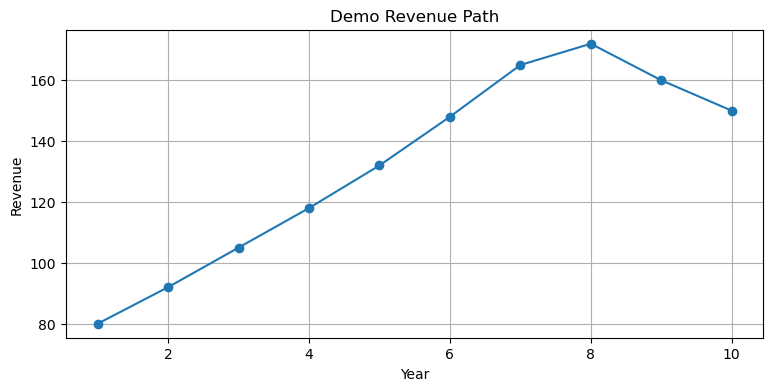

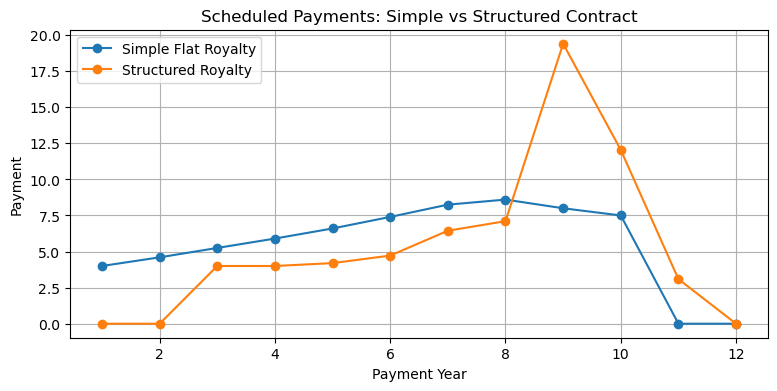

,Year,Revenue,Simple_Accrued,Structured_Accrued,Applied_Rate,Floor_Topup,Deferred_to_Reserve,Catchup_Released,Milestone
0,1,80.0,4.00,4.000,0.040,0.80,0.000,0.00,0.0
1,2,92.0,4.60,4.000,0.040,0.32,0.000,0.00,0.0
2,3,105.0,5.25,4.200,0.040,0.00,0.000,0.00,0.0
3,4,118.0,5.90,4.720,0.040,0.00,0.000,0.00,0.0
4,5,132.0,6.60,6.445,0.055,0.00,0.815,0.00,0.0
5,6,148.0,7.40,7.105,0.055,0.00,1.035,0.00,0.0
6,7,165.0,8.25,19.400,0.070,0.00,0.000,1.85,6.0
7,8,172.0,8.60,12.040,0.070,0.00,0.000,0.00,0.0
8,9,160.0,8.00,3.090,0.070,0.00,0.000,0.00,0.0
9,10,150.0,7.50,0.000,0.000,0.00,0.000,0.00,0.0


In [32]:
contract_schedule_compare = simple_schedule.merge(
    structured_schedule,
    on="Payment_Year",
    how="outer"
).fillna(0.0)

display(contract_schedule_compare.round(4))

plt.figure(figsize=(9, 4))
plt.plot(demo_years, demo_revenues, marker="o")
plt.title("Demo Revenue Path")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(
    contract_schedule_compare["Payment_Year"],
    contract_schedule_compare["Simple_Scheduled_Payment"],
    marker="o",
    label="Simple Flat Royalty"
)
plt.plot(
    contract_schedule_compare["Payment_Year"],
    contract_schedule_compare["Structured_Scheduled_Payment"],
    marker="o",
    label="Structured Royalty"
)
plt.title("Scheduled Payments: Simple vs Structured Contract")
plt.xlabel("Payment Year")
plt.ylabel("Payment")
plt.legend()
plt.grid(True)
plt.show()

contract_year_compare = simple_detail[["Year", "Revenue", "Accrued_Payment"]].rename(
    columns={"Accrued_Payment": "Simple_Accrued"}
).merge(
    structured_detail[["Year", "Accrued_Payment", "Applied_Rate", "Floor_Topup", "Deferred_to_Reserve", "Catchup_Released", "Milestone"]].rename(
        columns={"Accrued_Payment": "Structured_Accrued"}
    ),
    on="Year",
    how="left"
)

display(contract_year_compare.round(4))

### Contract-Level Monte Carlo Comparison
This stylised simulation compares the value and downside risk of a simple royalty contract versus a more structured contract with tiering, floor, cap, lag, milestone, and catch-up mechanics.

,Contract,NPV_Mean,NPV_P10,NPV_CVaR_5,Prob_NPV_Negative,Mean_Total_Payout
0,Simple Flat Royalty,38.3170,33.6541,31.2454,0.0,66.2695
1,Structured Royalty,32.6261,30.5068,27.6718,0.0,64.6161


,Metric,Structured_minus_Simple
0,Delta_NPV_Mean,-5.6908
1,Delta_NPV_P10,-3.1473
2,Delta_NPV_CVaR_5,-3.5737
3,Delta_Prob_NPV_Negative,0.0000
4,Delta_Mean_Total_Payout,-1.6534


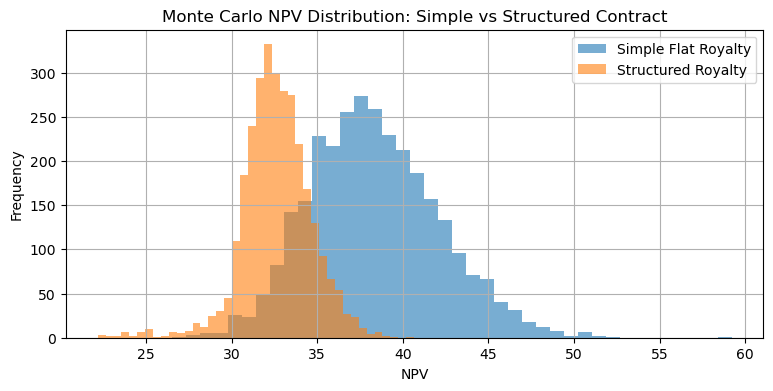

In [33]:
# ======================================
# CONTRACT-LEVEL MONTE CARLO COMPARISON
# ======================================

rng = np.random.default_rng(42)
n_demo_sims = 3000
sigma_demo = 0.30


def left_tail_cvar(x, alpha=0.05):
    cutoff = np.quantile(x, alpha)
    tail = x[x <= cutoff]
    return float(np.mean(tail)) if len(tail) > 0 else np.nan


simple_npv_paths = []
structured_npv_paths = []
simple_total_paths = []
structured_total_paths = []

for _ in range(n_demo_sims):
    shocks = np.exp(
        rng.normal(
            loc=-0.5 * sigma_demo**2,
            scale=sigma_demo,
            size=len(demo_revenues)
        )
    )
    revenue_path = demo_revenues * shocks

    _, _, s_npv, s_total = build_contract_cashflows(revenue_path, DEMO_CONTRACT, kind="simple")
    _, _, st_npv, st_total = build_contract_cashflows(revenue_path, DEMO_CONTRACT, kind="structured")

    simple_npv_paths.append(s_npv)
    structured_npv_paths.append(st_npv)
    simple_total_paths.append(s_total)
    structured_total_paths.append(st_total)

simple_npv_paths = np.array(simple_npv_paths)
structured_npv_paths = np.array(structured_npv_paths)
simple_total_paths = np.array(simple_total_paths)
structured_total_paths = np.array(structured_total_paths)

contract_mc_summary = pd.DataFrame({
    "Contract": ["Simple Flat Royalty", "Structured Royalty"],
    "NPV_Mean": [simple_npv_paths.mean(), structured_npv_paths.mean()],
    "NPV_P10": [np.quantile(simple_npv_paths, 0.10), np.quantile(structured_npv_paths, 0.10)],
    "NPV_CVaR_5": [left_tail_cvar(simple_npv_paths), left_tail_cvar(structured_npv_paths)],
    "Prob_NPV_Negative": [(simple_npv_paths < 0).mean(), (structured_npv_paths < 0).mean()],
    "Mean_Total_Payout": [simple_total_paths.mean(), structured_total_paths.mean()],
})

display(contract_mc_summary.round(4))

contract_mc_delta = pd.DataFrame({
    "Metric": [
        "Delta_NPV_Mean",
        "Delta_NPV_P10",
        "Delta_NPV_CVaR_5",
        "Delta_Prob_NPV_Negative",
        "Delta_Mean_Total_Payout",
    ],
    "Structured_minus_Simple": [
        contract_mc_summary.loc[1, "NPV_Mean"] - contract_mc_summary.loc[0, "NPV_Mean"],
        contract_mc_summary.loc[1, "NPV_P10"] - contract_mc_summary.loc[0, "NPV_P10"],
        contract_mc_summary.loc[1, "NPV_CVaR_5"] - contract_mc_summary.loc[0, "NPV_CVaR_5"],
        contract_mc_summary.loc[1, "Prob_NPV_Negative"] - contract_mc_summary.loc[0, "Prob_NPV_Negative"],
        contract_mc_summary.loc[1, "Mean_Total_Payout"] - contract_mc_summary.loc[0, "Mean_Total_Payout"],
    ]
})

display(contract_mc_delta.round(4))

plt.figure(figsize=(9, 4))
plt.hist(simple_npv_paths, bins=40, alpha=0.6, label="Simple Flat Royalty")
plt.hist(structured_npv_paths, bins=40, alpha=0.6, label="Structured Royalty")
plt.title("Monte Carlo NPV Distribution: Simple vs Structured Contract")
plt.xlabel("NPV")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Key Insights from Contract Design

The comparison highlights that contractual structure is a key driver of both value and risk:

- The structured contract reduces NPV due to caps, payment lag, and lower effective early cashflows
- Upside participation is partially limited, while downside protection is only partially improved
- Timing effects (payment lag and catch-up) significantly affect present value
- Contractual features introduce non-linear payoff structures that are not captured by simple flat royalty assumptions

This demonstrates that accurate valuation of royalty investments requires explicit modelling of contract mechanics.

## 11. Investment Decision Framework

**Decision threshold calibration**

A stricter downside threshold (30%) is applied for a full "INVEST" classification, even though the hard investment gate allows up to 40%.

This introduces a conservative bias in final approval and ensures that only cases with stronger downside protection receive an unconditional invest label.

In [34]:
# ===========================================
# INVESTMENT DECISION FRAMEWORK (UNDERWRITING VERSION)
# ===========================================

irr = results["monte_carlo"]["irr_mean"]
moic = results["monte_carlo"]["moic_mean"]
npv = results["monte_carlo"]["npv_mean"]

prob_neg = results["risk"]["prob_npv_negative"]
npv_cvar = results["risk"]["npv_cvar_5"]

valuation_discount_rate = CONFIG["valuation_discount_rate"]
hurdle_rate = CONFIG["hurdle_rate"]

# --- Hard gates
gate_irr_ok = irr >= hurdle_rate
gate_moic_ok = moic >= 2.0
gate_prob_ok = prob_neg < 0.40
gate_cvar_ok = npv_cvar > -20

hard_gate_pass = all([
    gate_irr_ok,
    gate_moic_ok,
    gate_prob_ok,
    gate_cvar_ok
])

# --- Return score
return_score = 0

if irr >= hurdle_rate + 0.02:
    return_score += 3
elif irr >= hurdle_rate:
    return_score += 2
elif irr >= hurdle_rate - 0.01:
    return_score += 1

if moic >= 2.5:
    return_score += 2
elif moic >= 2.0:
    return_score += 1

if npv > 0:
    return_score += 1

# --- Risk score
risk_score = 0

if prob_neg <= 0.20:
    risk_score += 2
elif prob_neg <= 0.40:
    risk_score += 1

if npv_cvar > -10:
    risk_score += 2
elif npv_cvar > -20:
    risk_score += 1

total_score = return_score + risk_score

# --- Final decision
if hard_gate_pass and total_score >= 6 and prob_neg <= 0.30:
    final_decision = "INVEST"
elif total_score >= 4:
    final_decision = "INVEST WITH CONDITIONS"
else:
    final_decision = "REJECT"

# --- Risk flag
if prob_neg > 0.50:
    risk_flag = "HIGH DOWNSIDE RISK"
elif prob_neg > 0.35:
    risk_flag = "ELEVATED DOWNSIDE RISK"
elif prob_neg > 0.20:
    risk_flag = "MODERATE DOWNSIDE RISK"
else:
    risk_flag = "ACCEPTABLE DOWNSIDE RISK"

# --- Primary driver
if "top_drivers" in globals() and not top_drivers.empty:
    primary_driver = top_drivers.iloc[0]["Driver"]
else:
    primary_driver = "Valuation Discount Rate"

# --- Underwriting reasons
underwriting_reasons = []

if irr >= hurdle_rate:
    underwriting_reasons.append(
        f"Return clears hurdle by {irr - hurdle_rate:+.2%}."
    )
else:
    underwriting_reasons.append(
        f"Return misses hurdle by {irr - hurdle_rate:+.2%}."
    )

if prob_neg > 0.30:
    underwriting_reasons.append(
        f"Downside probability is elevated at {prob_neg:.2%}, which limits valuation buffer."
    )
else:
    underwriting_reasons.append(
        f"Downside probability remains acceptable at {prob_neg:.2%}."
    )

if npv_cvar <= -20:
    underwriting_reasons.append(
        f"Tail-risk remains severe with NPV CVaR (5%) of {npv_cvar:.2f}."
    )
else:
    underwriting_reasons.append(
        f"Tail-risk remains manageable with NPV CVaR (5%) of {npv_cvar:.2f}."
    )

underwriting_reasons.append(
    f"Primary value driver is currently: {primary_driver}."
)

if primary_driver == "Scenario Layer":
    underwriting_reasons.append(
        "Joint scenario assumptions around discount rate, exit multiple and volatility drive overall robustness."
    )
elif primary_driver == "Valuation Discount Rate":
    underwriting_reasons.append(
        "The investment case is especially sensitive to required-return assumptions and long-duration valuation effects."
    )
else:
    underwriting_reasons.append(
        "Contract mechanics, payout timing and structural economics materially influence value and downside."
    )

decision_df = pd.DataFrame([{
    "Valuation_Discount_Rate": valuation_discount_rate,
    "Hurdle_Rate": hurdle_rate,
    "IRR_Mean": irr,
    "MOIC_Mean": moic,
    "NPV_Mean": npv,
    "Prob_NPV_Negative": prob_neg,
    "NPV_CVaR_5": npv_cvar,
    "Return_Score": return_score,
    "Risk_Score": risk_score,
    "Total_Score": total_score,
    "Hard_Gates_Passed": hard_gate_pass,
    "FINAL_DECISION": final_decision,
    "Risk_Flag": risk_flag,
    "Primary_Driver": primary_driver,
}])

underwriting_explanation_df = pd.DataFrame({
    "Underwriting_Explanation": underwriting_reasons
})

print("=== INVESTMENT DECISION ===")
display(decision_df.style.hide(axis="index"))

print("=== UNDERWRITING EXPLANATION ===")
display(underwriting_explanation_df.style.hide(axis="index"))

=== INVESTMENT DECISION ===


Valuation_Discount_Rate,Hurdle_Rate,IRR_Mean,MOIC_Mean,NPV_Mean,Prob_NPV_Negative,NPV_CVaR_5,Return_Score,Risk_Score,Total_Score,Hard_Gates_Passed,FINAL_DECISION,Risk_Flag,Primary_Driver
0.100000,0.100000,0.104902,2.819305,4.737750,0.336333,-13.544970,5,2,7,True,INVEST WITH CONDITIONS,MODERATE DOWNSIDE RISK,Scenario Layer


=== UNDERWRITING EXPLANATION ===


Underwriting_Explanation
Return clears hurdle by +0.49%.
"Downside probability is elevated at 33.63%, which limits valuation buffer."
Tail-risk remains manageable with NPV CVaR (5%) of -13.54.
Primary value driver is currently: Scenario Layer.
"Joint scenario assumptions around discount rate, exit multiple and volatility drive overall robustness."


### Decision Logic Interpretation

The investment decision is based on a structured framework combining return expectations, downside risk, and minimum investment criteria.

**Hard Investment Gates** define minimum requirements (IRR, MOIC, NPV, probability of negative NPV, and CVaR) and ensure that no investment is approved if core economic conditions are not met.

**Return and Risk Scores** provide a balanced view of expected performance and downside exposure, combining upside potential with tail-risk considerations.

**Final Decision**
- **INVEST**: strong overall risk-return profile with acceptable downside risk  
- **INVEST WITH CONDITIONS**: economically viable, but requires further structuring, validation, or monitoring  
- **REJECT**: insufficient return and/or excessive downside risk  

**Risk Flag**
A separate downside risk classification (acceptable to high) ensures transparency and supports both investment decision-making and ongoing monitoring.

Overall, the framework is designed as a decision-support tool that integrates valuation, risk assessment, and investment judgment in a consistent and transparent manner.

## 12. Management Summary (Reference-Case IC View)

In [35]:
# ===========================================
# MANAGEMENT SUMMARY (FINAL)
# ===========================================

irrmean = results["monte_carlo"]["irr_mean"]
moicmean = results["monte_carlo"]["moic_mean"]
npvmean = results["monte_carlo"]["npv_mean"]

probneg = results["risk"]["prob_npv_negative"]
npvcvar5 = results["risk"]["npv_cvar_5"]

valuation_discount_rate = CONFIG["valuation_discount_rate"]
hurdle_rate = CONFIG["hurdle_rate"]
gross_target = CONFIG.get("illustrative_gross_target_return", hurdle_rate + 0.05)

final_decision = decision_df.loc[0, "FINAL_DECISION"]
riskflag = decision_df.loc[0, "Risk_Flag"]
primary_driver = decision_df.loc[0, "Primary_Driver"]

if "scenario_df" in globals() and not scenario_df.empty:
    scen_best_idx = scenario_df["NPV_Mean"].idxmax()
    scen_worst_idx = scenario_df["NPV_Mean"].idxmin()

    scen_best = scenario_df.loc[scen_best_idx, "Scenario"]
    scen_best_npv = float(scenario_df.loc[scen_best_idx, "NPV_Mean"])
    scen_worst = scenario_df.loc[scen_worst_idx, "Scenario"]
    scen_worst_npv = float(scenario_df.loc[scen_worst_idx, "NPV_Mean"])
else:
    scen_best = "N/A"
    scen_best_npv = np.nan
    scen_worst = "N/A"
    scen_worst_npv = np.nan

# Reconciliation status text
if "reconciliation_df" in globals():
    reconciliation_matches = int((reconciliation_df["Status"] == "MATCH").sum())
    reconciliation_total = int(len(reconciliation_df))
    reconciliation_statement = (
        f"Deterministic reconciliation status: {reconciliation_matches}/{reconciliation_total} metrics currently marked as MATCH against the Excel ground truth."
    )
else:
    reconciliation_statement = (
        "Deterministic reconciliation table not available in this run."
    )

# Underwriting rationale block
if "underwriting_explanation_df" in globals():
    underwriting_lines = underwriting_explanation_df["Underwriting_Explanation"].tolist()
else:
    underwriting_lines = [
        "Return/risk explanation not available in this run."
    ]

management_summary = f"""
INVESTMENT COMMITTEE SUMMARY

1. Overall Assessment
Decision: {final_decision}
Risk classification: {riskflag}

2. Return and Valuation
IRR mean is {irrmean:.2%} versus hurdle rate {hurdle_rate:.2%}.
Expected NPV is {npvmean:.2f} at a valuation discount rate of {valuation_discount_rate:.2%}.
MOIC mean is {moicmean:.2f}x.

3. Downside Risk
Probability of negative investor NPV is {probneg:.2%}.
NPV CVaR (5%) is {npvcvar5:.2f}.

4. Deterministic Reference vs Stochastic Extension
The deterministic reference case acts as the calibration anchor.
Monte Carlo extends the same calibrated cashflow base with stochastic uncertainty.
{reconciliation_statement}

5. Primary Underwriting Rationale
- {underwriting_lines[0]}
- {underwriting_lines[1]}
- {underwriting_lines[2]}
- {underwriting_lines[3]}
- {underwriting_lines[4]}

6. Scenario Context
Best current scenario: {scen_best} with expected NPV {scen_best_npv:.2f}.
Weakest current scenario: {scen_worst} with expected NPV {scen_worst_npv:.2f}.

7. Main Driver
Primary driver currently identified: {primary_driver}.

8. Fund-Level Bridge
Illustrative gross target return implied by hurdle, fee drag and carry assumptions: {gross_target:.2%}.
""".strip()

print(management_summary)

INVESTMENT COMMITTEE SUMMARY

1. Overall Assessment
Decision: INVEST WITH CONDITIONS
Risk classification: MODERATE DOWNSIDE RISK

2. Return and Valuation
IRR mean is 10.49% versus hurdle rate 10.00%.
Expected NPV is 4.74 at a valuation discount rate of 10.00%.
MOIC mean is 2.82x.

3. Downside Risk
Probability of negative investor NPV is 33.63%.
NPV CVaR (5%) is -13.54.

4. Deterministic Reference vs Stochastic Extension
The deterministic reference case acts as the calibration anchor.
Monte Carlo extends the same calibrated cashflow base with stochastic uncertainty.
Deterministic reconciliation status: 1/5 metrics currently marked as MATCH against the Excel ground truth.

5. Primary Underwriting Rationale
- Return clears hurdle by +0.49%.
- Downside probability is elevated at 33.63%, which limits valuation buffer.
- Tail-risk remains manageable with NPV CVaR (5%) of -13.54.
- Primary value driver is currently: Scenario Layer.
- Joint scenario assumptions around discount rate, exit multi

### Management Summary Interpretation

This section condenses the full model output into an investment-committee style summary.

It combines:

- base-case valuation
- downside risk
- discount-rate sensitivity
- macro/scenario context
- royalty contract intelligence
- final decision and monitoring relevance

The objective is not only to value the case, but to present the investment in a way that supports real-world discussion, review, and monitoring.

## 13. Export & Output Directory

In [36]:
# ======================================
# OUTPUT DIRECTORY
# ======================================

OUTPUT_DIR = project_root / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: C:\Users\Noah\PG3_Royalty_Python_Model\outputs


In [37]:
# ======================================
# EXPORT OUTPUTS (FINAL, ROBUST)
# ======================================

from datetime import datetime
from pathlib import Path

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_folder = OUTPUT_DIR / f"run_{timestamp}"
run_folder.mkdir(exist_ok=True)

def export_if_exists(var_name, filename, as_txt=False):
    if var_name in globals():
        obj = globals()[var_name]

        if as_txt:
            with open(run_folder / filename, "w", encoding="utf-8") as f:
                f.write(str(obj))
        else:
            if isinstance(obj, pd.DataFrame):
                obj.to_csv(run_folder / filename, index=False)
            elif isinstance(obj, dict):
                pd.DataFrame([obj]).to_csv(run_folder / filename, index=False)
            else:
                try:
                    pd.DataFrame(obj).to_csv(run_folder / filename, index=False)
                except Exception:
                    pass

# --------------------------------------
# Core outputs
# --------------------------------------
export_if_exists("decision_df", "decision_summary.csv")
export_if_exists("scenario_df", "scenario_comparison.csv")
export_if_exists("target_df", "target_return_sensitivity.csv")

# --------------------------------------
# Driver outputs
# --------------------------------------
export_if_exists("driver_df", "driver_scenarios.csv")
export_if_exists("impact_df", "driver_impact_summary.csv")
export_if_exists("driver_importance_df", "driver_importance_summary.csv")

# --------------------------------------
# Entry sensitivity
# --------------------------------------
export_if_exists("entry_df", "entry_multiple_sensitivity.csv")

# --------------------------------------
# Calibration outputs
# --------------------------------------
export_if_exists("headline_comparison", "calibration_summary.csv")
export_if_exists("equity_cf_comparison", "calibration_selected_years.csv")

# --------------------------------------
# Contract intelligence outputs
# --------------------------------------
export_if_exists("contract_det_summary", "contract_deterministic_summary.csv")
export_if_exists("contract_mc_summary", "contract_mc_summary.csv")
export_if_exists("contract_mc_delta", "contract_mc_delta.csv")
export_if_exists("contract_schedule_compare", "contract_schedule_comparison.csv")
export_if_exists("contract_year_compare", "contract_year_comparison.csv")

# --------------------------------------
# Narrative outputs
# --------------------------------------
export_if_exists("management_summary", "management_summary.txt", as_txt=True)
export_if_exists("driver_statement", "driver_statement.txt", as_txt=True)
export_if_exists("takeaway", "driver_takeaway.txt", as_txt=True)

# --------------------------------------
# IC one-pager summary
# --------------------------------------
decision_pack = {
    "Investor_Target_Return": CONFIG.get("investor_target_return", np.nan),
    "IRR": irr if "irr" in globals() else np.nan,
    "MOIC": moic if "moic" in globals() else np.nan,
    "NPV": npv if "npv" in globals() else np.nan,
    "Prob_NPV_Neg": prob_neg if "prob_neg" in globals() else np.nan,
    "Decision": final_decision if "final_decision" in globals() else None,
    "Risk_Flag": risk_flag if "risk_flag" in globals() else None,
    "Top_Driver": top_driver if "top_driver" in globals() else None,
}
pd.DataFrame([decision_pack]).to_csv(run_folder / "IC_one_pager.csv", index=False)

# --------------------------------------
# Tail overlay stats
# --------------------------------------
if "results" in globals() and isinstance(results, dict) and "tail_overlay" in results:
    tail_df = pd.DataFrame([results["tail_overlay"]])
else:
    tail_df = pd.DataFrame([{
        "tail_event_count": np.nan,
        "super_tail_event_count": np.nan
    }])

tail_df.to_csv(run_folder / "tail_overlay_summary.csv", index=False)

# --------------------------------------
# Print export path
# --------------------------------------
print(f"Outputs exported to: {run_folder}")

Outputs exported to: C:\Users\Noah\PG3_Royalty_Python_Model\outputs\run_20260420_140924
